## Clustering Analysis - FIFA 23 Players

Σε αυτό το notebook εφαρμόζεται ομαδοποίηση (clustering) σε δεδομένα παικτών από το FIFA 23.

Ο στόχος είναι να βρούμε ομάδες παικτών με παρόμοια χαρακτηριστικά, όπως overall rating, pace, shooting, passing, dribbling, defending και physicality.

Σε αντίθεση με το regression και το classification, στο clustering δεν υπάρχει target variable. Το μοντέλο δεν προσπαθεί να προβλέψει μια γνωστή απάντηση, αλλά προσπαθεί να ανακαλύψει φυσικές ομάδες μέσα στα δεδομένα.

## 1. import Libraries

In [1]:
# Βασικές βιβλιοθήκες για επεξεργασία δεδομένων
import pandas as pd
import numpy as np

# Βιβλιοθήκη για γραφήματα
import matplotlib.pyplot as plt

# Εργαλεία για διαχωρισμό και επεξεργασία δεδομένων
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Αλγόριθμοι clustering
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import DBSCAN

# Metrics για αξιολόγηση clustering
from sklearn.metrics import silhouette_score

# PCA για απεικόνιση των clusters σε 2 διαστάσεις
from sklearn.decomposition import PCA

# Για να εμφανίζονται τα γραφήματα μέσα στο notebook
%matplotlib inline

## 2. Loading and Description of Dataset

Σε αυτό το βήμα φορτώνουμε το FIFA 23 players dataset και ελέγχουμε τη βασική του δομή.

Το dataset περιέχει πληροφορίες για ποδοσφαιριστές, όπως ηλικία, ύψος, βάρος, overall rating, potential και τεχνικά χαρακτηριστικά.

In [2]:
# Φόρτωση του dataset
df = pd.read_csv('data/fifa23_players_clean.csv')
df.head() # Βλέπουμε τις 5 πρώτες γραμμές του dataset

,id,name,full_name,age,height,weight,photo_url,nationality,overall,potential,...,lm_rating,cm_rating,rm_rating,lwb_rating,cdm_rating,rwb_rating,lb_rating,cb_rating,rb_rating,gk_rating
0,158023,L. Messi,Lionel Messi,35,169,67,https://cdn.sofifa.net/players/158/023/23_60.png,Argentina,91,91,...,91,87,91,67,65,67,62,53,62,22
1,165153,K. Benzema,Karim Benzema,34,187,81,https://cdn.sofifa.net/players/165/153/23_60.png,France,91,91,...,89,84,89,67,67,67,63,58,63,21
2,188545,R. Lewandowski,Robert Lewandowski,33,185,81,https://cdn.sofifa.net/players/188/545/23_60.png,Poland,91,91,...,86,83,86,67,69,67,64,63,64,22
3,190871,Neymar Jr,Neymar da Silva Santos Jr.,30,175,68,https://cdn.sofifa.net/players/190/871/23_60.png,Brazil,91,91,...,91,85,91,69,66,69,65,54,65,23
4,192119,T. Courtois,Thibaut Courtois,30,199,96,https://cdn.sofifa.net/players/192/119/23_60.png,Belgium,91,92,...,34,36,34,32,34,32,32,32,32,91


In [3]:
# Βασικές πληροφορίες στηλών και τύπων δεδομένων
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1221 entries, 0 to 1220
Data columns (total 82 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   id                   1221 non-null   int64 
 1   name                 1221 non-null   object
 2   full_name            1221 non-null   object
 3   age                  1221 non-null   int64 
 4   height               1221 non-null   int64 
 5   weight               1221 non-null   int64 
 6   photo_url            1221 non-null   object
 7   nationality          1221 non-null   object
 8   overall              1221 non-null   int64 
 9   potential            1221 non-null   int64 
 10  growth               1221 non-null   int64 
 11  total_stats          1221 non-null   int64 
 12  base_stats           1221 non-null   int64 
 13  positions            1221 non-null   object
 14  best_position        1221 non-null   object
 15  club                 1221 non-null   object
 16  nation

In [4]:
#Ονόματα στηλών
df.columns 

Index(['id', 'name', 'full_name', 'age', 'height', 'weight', 'photo_url',
       'nationality', 'overall', 'potential', 'growth', 'total_stats',
       'base_stats', 'positions', 'best_position', 'club', 'national_team',
       'national_position', 'national_number', 'preferred_foot',
       'int_reputation', 'weak_foot', 'skill_moves', 'attacking_work_rate',
       'defensive_work_rate', 'pace_total', 'shooting_total', 'passing_total',
       'dribbling_total', 'defending_total', 'physicality_total', 'crossing',
       'finishing', 'heading_accuracy', 'short_passing', 'volleys',
       'dribbling', 'curve', 'fk_accuracy', 'long_passing', 'ball_control',
       'acceleration', 'sprint_speed', 'agility', 'reactions', 'balance',
       'shot_power', 'jumping', 'stamina', 'strength', 'long_shots',
       'aggression', 'interceptions', 'positioning', 'vision', 'penalties',
       'composure', 'marking', 'standing_tackle', 'sliding_tackle',
       'gk_diving', 'gk_handling', 'gk_kicking', '

In [5]:
print("Μέγεθος dataset:", df.shape)

Μέγεθος dataset: (1221, 82)


## 3. Exploratory Data Analysis

In [6]:
# Επιλέγουμε βασικά αριθμητικά χαρακτηριστικά για την αρχική ανάλυση
eda_features = [
    'age',
    'overall',
    'potential',
    'pace_total',
    'shooting_total',
    'passing_total',
    'dribbling_total',
    'defending_total',
    'physicality_total'
]

# Εμφανίζουμε τις πρώτες γραμμές με αυτά τα χαρακτηριστικά
df[eda_features].head()

,age,overall,potential,pace_total,shooting_total,passing_total,dribbling_total,defending_total,physicality_total
0,35,91,91,81,89,89,94,34,64
1,34,91,91,80,88,83,87,39,78
2,33,91,91,75,91,79,86,44,83
3,30,91,91,87,87,84,94,38,61
4,30,91,92,87,89,75,90,48,89


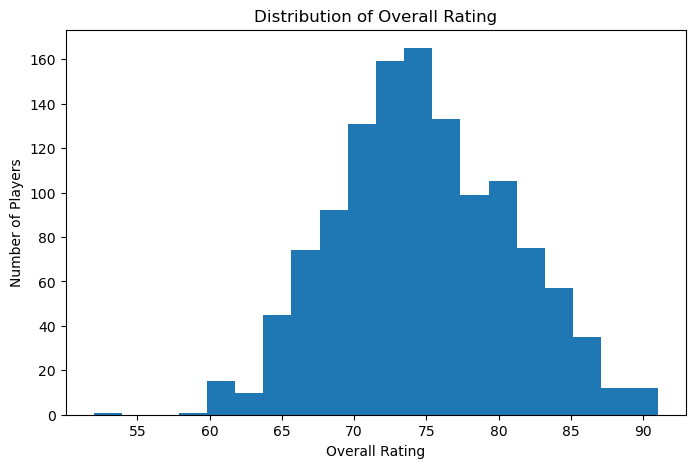

In [7]:
# Ιστόγραμμα για την κατανομή του overall rating των παικτών
plt.figure(figsize=(8, 5))

plt.hist(df['overall'], bins=20)

plt.title('Distribution of Overall Rating')
plt.xlabel('Overall Rating')
plt.ylabel('Number of Players')

plt.show()

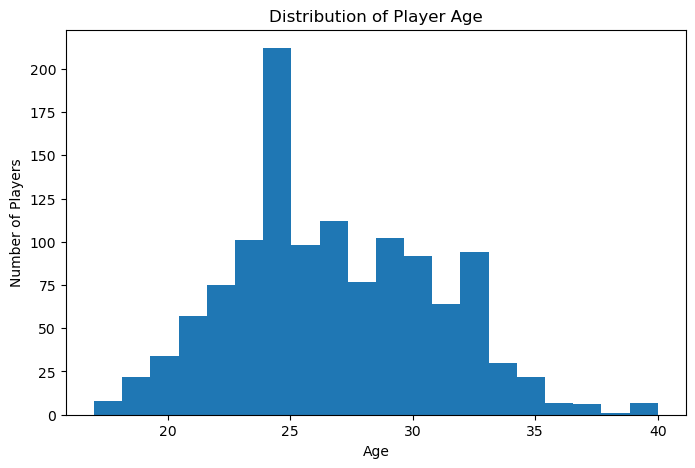

In [8]:
# Ιστόγραμμα για την κατανομή της ηλικίας των παικτών
plt.figure(figsize=(8, 5))

plt.hist(df['age'], bins=20)

plt.title('Distribution of Player Age')
plt.xlabel('Age')
plt.ylabel('Number of Players')

plt.show()

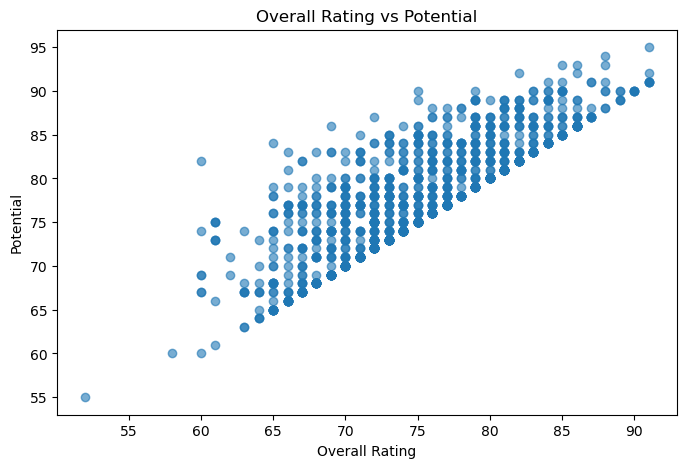

In [9]:
# Scatter plot για να δούμε τη σχέση ανάμεσα στο overall και το potential
plt.figure(figsize=(8, 5))

plt.scatter(df['overall'], df['potential'], alpha=0.6)

plt.title('Overall Rating vs Potential')
plt.xlabel('Overall Rating')
plt.ylabel('Potential')

plt.show()

In [10]:
# Υπολογίζουμε τον μέσο όρο βασικών χαρακτηριστικών
average_attributes = df[
    [
        'pace_total',
        'shooting_total',
        'passing_total',
        'dribbling_total',
        'defending_total',
        'physicality_total'
    ]
].mean()

average_attributes

pace_total           73.079443
shooting_total       62.690418
passing_total        67.135135
dribbling_total      71.628174
defending_total      57.754300
physicality_total    71.793612
dtype: float64

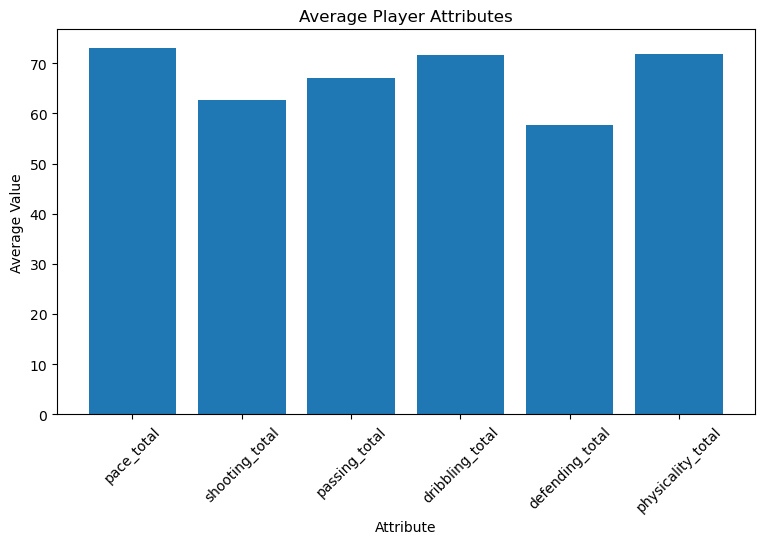

In [11]:
# Γράφημα με τους μέσους όρους των βασικών χαρακτηριστικών
plt.figure(figsize=(9, 5))

plt.bar(average_attributes.index, average_attributes.values)

plt.title('Average Player Attributes')
plt.xlabel('Attribute')
plt.ylabel('Average Value')

plt.xticks(rotation=45)

plt.show()

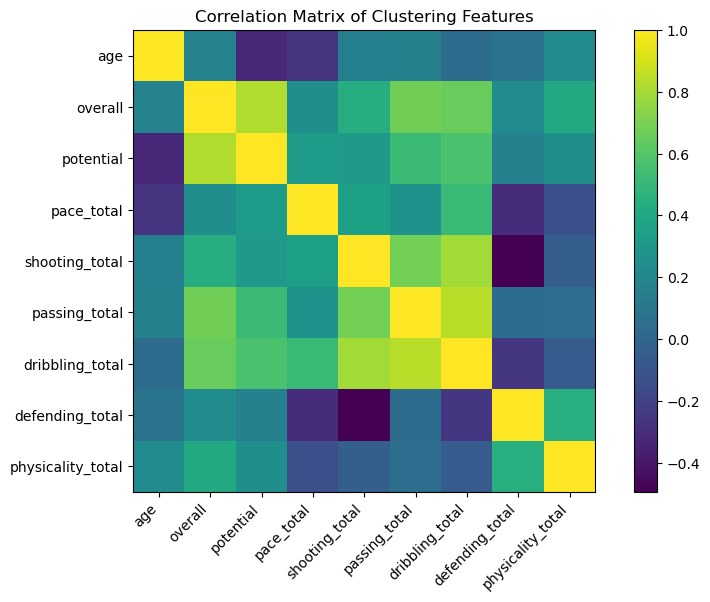

In [12]:
# Ελέγχουμε τη συσχέτιση μεταξύ βασικών αριθμητικών χαρακτηριστικών
correlation_matrix = df[eda_features].corr()

plt.figure(figsize=(10, 6))

plt.imshow(correlation_matrix)
plt.colorbar()

plt.xticks(range(len(eda_features)), eda_features, rotation=45, ha='right')
plt.yticks(range(len(eda_features)), eda_features)

plt.title('Correlation Matrix of Clustering Features')

plt.show()

## 4. Descriptive Statistics

Σε αυτό το βήμα εξετάζουμε βασικά στατιστικά στοιχεία για τα αριθμητικά χαρακτηριστικά που θα χρησιμοποιηθούν στο clustering.

Η περιγραφική στατιστική μας βοηθά να καταλάβουμε το εύρος, τον μέσο όρο και τη διασπορά των χαρακτηριστικών των παικτών πριν εφαρμόσουμε τους αλγόριθμους ομαδοποίησης.

In [13]:
# Επιλέγουμε τα αριθμητικά χαρακτηριστικά που θα χρησιμοποιηθούν για το clustering
clustering_features = [
    'age',
    'height',
    'weight',
    'overall',
    'potential',
    'pace_total',
    'shooting_total',
    'passing_total',
    'dribbling_total',
    'defending_total',
    'physicality_total'
]

# Εμφανίζουμε τις πρώτες γραμμές με τα χαρακτηριστικά clustering
df[clustering_features].head()

,age,height,weight,overall,potential,pace_total,shooting_total,passing_total,dribbling_total,defending_total,physicality_total
0,35,169,67,91,91,81,89,89,94,34,64
1,34,187,81,91,91,80,88,83,87,39,78
2,33,185,81,91,91,75,91,79,86,44,83
3,30,175,68,91,91,87,87,84,94,38,61
4,30,199,96,91,92,87,89,75,90,48,89


In [14]:
# Βλέπουμε βασικά στατιστικά στοιχεία για τα χαρακτηριστικά clustering
df[clustering_features].describe().round(2)

,age,height,weight,overall,potential,pace_total,shooting_total,passing_total,dribbling_total,defending_total,physicality_total
count,1221.00,1221.00,1221.00,1221.00,1221.00,1221.00,1221.00,1221.00,1221.00,1221.00,1221.00
mean,26.74,182.76,76.39,74.87,77.99,73.08,62.69,67.14,71.63,57.75,71.79
std,4.15,6.75,7.29,6.19,6.36,10.59,14.22,9.40,9.05,17.32,8.30
min,17.00,163.00,58.00,52.00,55.00,30.00,22.00,35.00,39.00,17.00,43.00
25%,24.00,178.00,71.00,71.00,74.00,67.00,55.00,62.00,67.00,43.00,67.00
50%,27.00,183.00,76.00,75.00,78.00,74.00,66.00,68.00,72.00,62.00,73.00
75%,30.00,188.00,81.00,79.00,83.00,81.00,73.00,73.00,78.00,72.00,78.00
max,40.00,203.00,102.00,91.00,95.00,97.00,92.00,93.00,94.00,91.00,91.00


In [15]:
# Βλέπουμε τους τύπους δεδομένων κάθε στήλης
df.dtypes

id             int64
name          object
full_name     object
age            int64
height         int64
               ...  
rwb_rating     int64
lb_rating      int64
cb_rating      int64
rb_rating      int64
gk_rating      int64
Length: 82, dtype: object

In [16]:
# Υπολογίζουμε τον μέσο όρο για κάθε χαρακτηριστικό clustering
feature_means = df[clustering_features].mean().round(2)

feature_means

age                   26.74
height               182.76
weight                76.39
overall               74.87
potential             77.99
pace_total            73.08
shooting_total        62.69
passing_total         67.14
dribbling_total       71.63
defending_total       57.75
physicality_total     71.79
dtype: float64

In [17]:
# Βλέπουμε την ελάχιστη και μέγιστη τιμή για κάθε χαρακτηριστικό
feature_min_max = df[clustering_features].agg(['min', 'max']).round(2)

feature_min_max

,age,height,weight,overall,potential,pace_total,shooting_total,passing_total,dribbling_total,defending_total,physicality_total
min,17,163,58,52,55,30,22,35,39,17,43
max,40,203,102,91,95,97,92,93,94,91,91


## 5. Data Preprocessing

In [18]:
# Δημιουργούμε το X για το clustering
# Δεν υπάρχει y, επειδή το clustering δεν έχει target variable
X_clustering = df[clustering_features]

print("Διαστάσεις X_clustering:", X_clustering.shape)

Διαστάσεις X_clustering: (1221, 11)


In [19]:
# Ελέγχουμε αν υπάρχουν κενές τιμές στα χαρακτηριστικά clustering
missing_values = X_clustering.isnull().sum()

missing_values

age                  0
height               0
weight               0
overall              0
potential            0
pace_total           0
shooting_total       0
passing_total        0
dribbling_total      0
defending_total      0
physicality_total    0
dtype: int64

In [20]:
# Δημιουργούμε pipeline για καθαρισμό και scaling των αριθμητικών δεδομένων
clustering_preprocessor = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

print("Το preprocessing pipeline δημιουργήθηκε με επιτυχία.")

Το preprocessing pipeline δημιουργήθηκε με επιτυχία.


In [21]:
# Εφαρμόζουμε το preprocessing στα δεδομένα clustering
X_clustering_processed = clustering_preprocessor.fit_transform(X_clustering)

print("Διαστάσεις πριν το preprocessing:", X_clustering.shape)
print("Διαστάσεις μετά το preprocessing:", X_clustering_processed.shape)

Διαστάσεις πριν το preprocessing: (1221, 11)
Διαστάσεις μετά το preprocessing: (1221, 11)


Στο preprocessing δημιουργήθηκε το `X_clustering`, το οποίο περιέχει μόνο τα αριθμητικά χαρακτηριστικά που θα χρησιμοποιηθούν για την ομαδοποίηση των παικτών.

Δεν δημιουργήθηκε `y`, επειδή στο clustering δεν υπάρχει target variable.

Οι πιθανές κενές τιμές αντιμετωπίστηκαν με τη διάμεσο τιμή, ενώ τα δεδομένα κανονικοποιήθηκαν με StandardScaler. Αυτό είναι σημαντικό, επειδή τα χαρακτηριστικά έχουν διαφορετικές κλίμακες, όπως ηλικία, ύψος, βάρος και τεχνικά ratings.

Μετά την προεπεξεργασία, οι διαστάσεις των δεδομένων παρέμειναν ίδιες, αλλά οι τιμές μετατράπηκαν σε κατάλληλη μορφή για clustering.

## 6. Application of Clustering Algorithms

Σε αυτό το βήμα εφαρμόζουμε διαφορετικούς clustering αλγόριθμους και διαφορετικές παραλλαγές τους.

Στόχος είναι να δούμε ποιος αλγόριθμος δημιουργεί πιο καθαρές και λογικές ομάδες παικτών με βάση τα χαρακτηριστικά τους.

Επειδή το clustering είναι unsupervised learning, δεν υπάρχει σωστή κατηγορία για σύγκριση. Για αυτό χρησιμοποιούμε metrics όπως το Silhouette Score.

In [22]:
# Συνάρτηση για να υπολογίζουμε το Silhouette Score με ασφάλεια
def calculate_silhouette(data, labels):
    
    # Βρίσκουμε πόσα διαφορετικά clusters δημιουργήθηκαν
    unique_labels = set(labels)
    
    # Το silhouette score χρειάζεται τουλάχιστον 2 clusters
    if len(unique_labels) > 1 and len(unique_labels) < len(labels):
        return silhouette_score(data, labels)
    else:
        return np.nan

In [23]:
# Δημιουργούμε κενή λίστα για να αποθηκεύσουμε τα αποτελέσματα
clustering_results = []

# Dictionary για να κρατήσουμε τα labels κάθε μοντέλου
cluster_labels = {}


# K-Means με διαφορετικές τιμές k
for k in [3, 4, 5]:
    
    model_name = f'K-Means k={k}'
    
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = model.fit_predict(X_clustering_processed)
    
    silhouette = calculate_silhouette(X_clustering_processed, labels)
    
    clustering_results.append({
        'Model': model_name,
        'Algorithm': 'K-Means',
        'Number of Clusters': k,
        'Silhouette Score': silhouette,
        'Inertia': model.inertia_,
        'Noise Points': 0
    })
    
    cluster_labels[model_name] = labels


# Agglomerative Clustering με διαφορετικό αριθμό clusters
for k in [3, 4, 5]:
    
    model_name = f'Agglomerative k={k}'
    
    model = AgglomerativeClustering(n_clusters=k)
    
    labels = model.fit_predict(X_clustering_processed)
    
    silhouette = calculate_silhouette(X_clustering_processed, labels)
    
    clustering_results.append({
        'Model': model_name,
        'Algorithm': 'Agglomerative Clustering',
        'Number of Clusters': k,
        'Silhouette Score': silhouette,
        'Inertia': np.nan,
        'Noise Points': 0
    })
    
    cluster_labels[model_name] = labels


# DBSCAN με διαφορετικές τιμές eps
for eps in [1.5, 2.0, 2.5]:
    
    model_name = f'DBSCAN eps={eps}'
    
    model = DBSCAN(
        eps=eps,
        min_samples=5
    )
    
    labels = model.fit_predict(X_clustering_processed)
    
    # Στο DBSCAN το -1 σημαίνει noise points
    number_of_clusters = len(set(labels) - {-1})
    noise_points = list(labels).count(-1)
    
    silhouette = calculate_silhouette(X_clustering_processed, labels)
    
    clustering_results.append({
        'Model': model_name,
        'Algorithm': 'DBSCAN',
        'Number of Clusters': number_of_clusters,
        'Silhouette Score': silhouette,
        'Inertia': np.nan,
        'Noise Points': noise_points
    })
    
    cluster_labels[model_name] = labels


print("Οι clustering αλγόριθμοι εφαρμόστηκαν με επιτυχία.")

Οι clustering αλγόριθμοι εφαρμόστηκαν με επιτυχία.


In [24]:
# Μετατρέπουμε τα αποτελέσματα σε DataFrame
clustering_results_df = pd.DataFrame(clustering_results)

# Ταξινομούμε με βάση το Silhouette Score
clustering_results_df = clustering_results_df.sort_values(
    by='Silhouette Score',
    ascending=False,
    na_position='last'
)

clustering_results_df.round(4)

,Model,Algorithm,Number of Clusters,Silhouette Score,Inertia,Noise Points
8,DBSCAN eps=2.5,DBSCAN,1,0.3063,NaN,10
7,DBSCAN eps=2.0,DBSCAN,1,0.2398,NaN,35
0,K-Means k=3,K-Means,3,0.1795,8930.8191,0
2,K-Means k=5,K-Means,5,0.1757,7276.6312,0
1,K-Means k=4,K-Means,4,0.1680,7963.4738,0
5,Agglomerative k=5,Agglomerative Clustering,5,0.1409,NaN,0
3,Agglomerative k=3,Agglomerative Clustering,3,0.1374,NaN,0
4,Agglomerative k=4,Agglomerative Clustering,4,0.1274,NaN,0
6,DBSCAN eps=1.5,DBSCAN,3,-0.0437,NaN,322


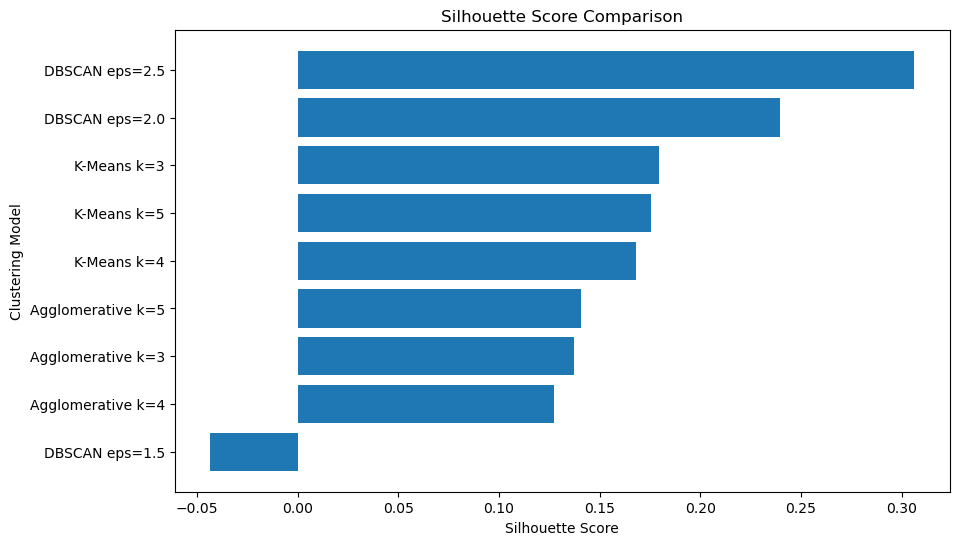

In [25]:
# Κρατάμε μόνο τα μοντέλα που έχουν έγκυρο Silhouette Score
silhouette_plot_data = clustering_results_df.dropna(subset=['Silhouette Score'])

plt.figure(figsize=(10, 6))

plt.barh(
    silhouette_plot_data['Model'],
    silhouette_plot_data['Silhouette Score']
)

plt.title('Silhouette Score Comparison')
plt.xlabel('Silhouette Score')
plt.ylabel('Clustering Model')

plt.gca().invert_yaxis()

plt.show()

Ο πίνακας συγκρίνει διαφορετικούς clustering αλγόριθμους και παραλλαγές τους με βάση το Silhouette Score, το Inertia και τα Noise Points.

Το Silhouette Score δείχνει πόσο καλά έχουν χωριστεί τα clusters. Γενικά, όσο πιο κοντά είναι η τιμή στο 1, τόσο καλύτερο είναι το clustering.

Παρόλο που το DBSCAN με `eps=2.5` και `eps=2.0` εμφανίζει υψηλότερο Silhouette Score, δημιούργησε μόνο ένα πραγματικό cluster, κάτι που δεν είναι χρήσιμο για την ανάλυση.

Η καλύτερη πρακτική επιλογή είναι το `K-Means k=3`, επειδή δημιουργεί τρία κανονικά clusters, δεν έχει noise points και έχει το καλύτερο Silhouette Score ανάμεσα στα χρήσιμα multi-cluster μοντέλα.

Το Silhouette Score είναι σχετικά χαμηλό, κάτι που δείχνει ότι οι ομάδες παικτών δεν είναι απόλυτα ξεκάθαρες. Αυτό είναι λογικό, επειδή πολλοί ποδοσφαιριστές έχουν παρόμοια ή μικτά χαρακτηριστικά.

## 7. Evaluation

In [26]:
# Επιλέγουμε το καλύτερο πρακτικά χρήσιμο clustering μοντέλο
best_clustering_model_name = 'K-Means k=3'

best_cluster_labels = cluster_labels[best_clustering_model_name]

print("Καλύτερο clustering μοντέλο:", best_clustering_model_name)

Καλύτερο clustering μοντέλο: K-Means k=3


In [27]:
# Δημιουργούμε αντίγραφο του dataset για να προσθέσουμε τα cluster labels
df_clusters = df.copy()

# Προσθέτουμε τη στήλη cluster
df_clusters['cluster'] = best_cluster_labels

df_clusters[['name', 'best_position', 'cluster']].head()

,name,best_position,cluster
0,L. Messi,RW,0
1,K. Benzema,ST,0
2,R. Lewandowski,ST,0
3,Neymar Jr,CF,0
4,T. Courtois,GK,0


In [28]:
# Μετράμε πόσοι παίκτες ανήκουν σε κάθε cluster
cluster_counts = df_clusters['cluster'].value_counts().sort_index()

cluster_counts

cluster
0    465
1    296
2    460
Name: count, dtype: int64

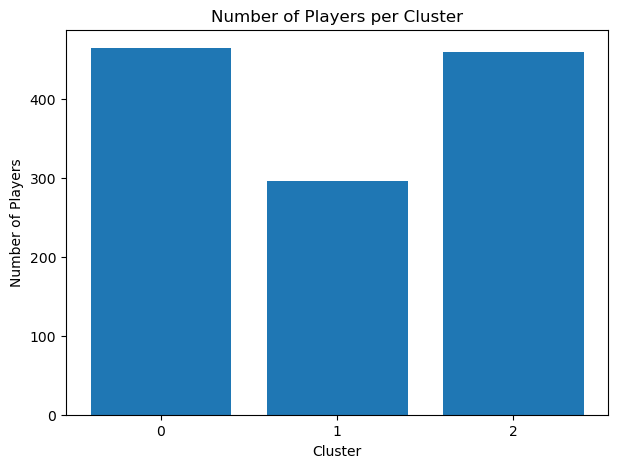

In [29]:
# Bar Plot για το μέγεθος κάθε cluster
plt.figure(figsize=(7, 5))

plt.bar(cluster_counts.index.astype(str), cluster_counts.values)

plt.title('Number of Players per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Number of Players')

plt.show()

In [30]:
# Υπολογίζουμε τον μέσο όρο των χαρακτηριστικών για κάθε cluster
cluster_profile = df_clusters.groupby('cluster')[clustering_features].mean().round(2)

cluster_profile

,age,height,weight,overall,potential,pace_total,shooting_total,passing_total,dribbling_total,defending_total,physicality_total
cluster,,,,,,,,,,,
0,27.30,183.28,77.45,80.38,82.75,76.43,72.78,75.13,79.25,57.97,74.77
1,27.52,187.00,80.70,72.93,75.70,64.15,46.07,58.41,61.03,70.51,76.31
2,25.68,179.50,72.56,70.56,74.65,75.43,63.19,64.66,70.74,49.33,65.88


Ο πίνακας δείχνει τους μέσους όρους των βασικών χαρακτηριστικών για κάθε cluster.

Το Cluster 0 φαίνεται να περιλαμβάνει τους πιο ποιοτικούς και τεχνικά δυνατούς παίκτες. Έχει το υψηλότερο `overall`, `potential`, `passing_total`, `dribbling_total` και αρκετά καλό `shooting_total`.

Το Cluster 1 φαίνεται να περιλαμβάνει πιο αμυντικούς και σωματικά δυνατούς παίκτες. Έχει υψηλότερο `height`, `weight`, `defending_total` και `physicality_total`, αλλά χαμηλότερο `shooting_total`.

Το Cluster 2 φαίνεται να περιλαμβάνει πιο γρήγορους και μέτριου επιπέδου παίκτες. Έχει καλό `pace_total` και `dribbling_total`, αλλά χαμηλότερο `overall` και `defending_total`.

Συνολικά, το K-Means με `k=3` κατάφερε να χωρίσει τους παίκτες σε τρεις γενικές ομάδες: ποιοτικοί/τεχνικοί παίκτες, αμυντικοί/σωματικά δυνατοί παίκτες και γρήγοροι παίκτες μέτριου επιπέδου.

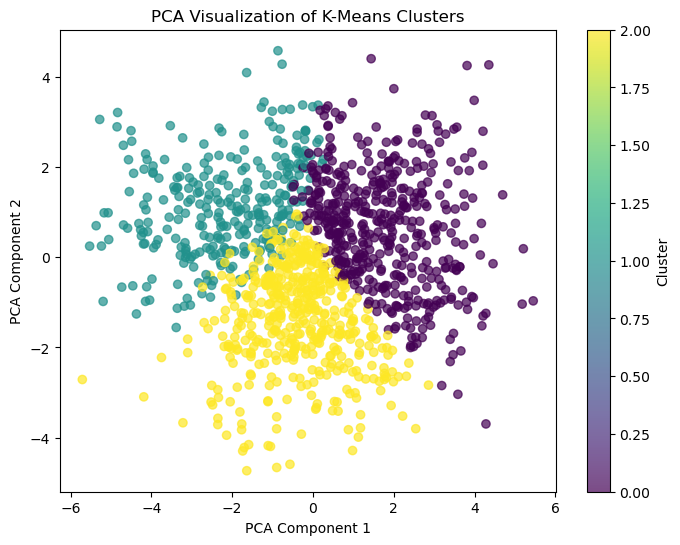

In [31]:
# Χρησιμοποιούμε PCA για να μειώσουμε τα δεδομένα σε 2 διαστάσεις
# Αυτό βοηθά να δούμε τα clusters σε γράφημα
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_clustering_processed)

plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=best_cluster_labels,
    alpha=0.7
)

plt.title('PCA Visualization of K-Means Clusters')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')

plt.colorbar(label='Cluster')

plt.show()

Το PCA χρησιμοποιήθηκε για να μειώσει τα πολλά αριθμητικά χαρακτηριστικά των παικτών σε δύο βασικές διαστάσεις, ώστε τα clusters να μπορούν να απεικονιστούν σε ένα απλό 2D γράφημα.

Το PCA Component 1 και το PCA Component 2 δεν αντιστοιχούν σε ένα μόνο αρχικό χαρακτηριστικό, αλλά είναι συνδυασμοί πολλών χαρακτηριστικών μαζί.

Το γράφημα βοηθά να δούμε οπτικά αν τα clusters που δημιούργησε το K-Means είναι σχετικά ξεχωριστά ή αν οι ομάδες παικτών μπερδεύονται μεταξύ τους.